In [1]:
# Basic libraries
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
from math import ceil
from collections import defaultdict
#from tqdm.notebook import tqdm        # Progress bar library for Jupyter Notebook
from tqdm import tqdm

# Deep learning framework for building and training models
import tensorflow as tf
## Pre-trained model for image feature extraction
from keras._tf_keras.keras.applications.vgg16 import VGG16, preprocess_input
from keras._tf_keras.keras.preprocessing.image import load_img, img_to_array

## Tokenizer class for captions tokenization
from keras._tf_keras.keras.preprocessing.text import Tokenizer

## Function for padding sequences to a specific length
from keras._tf_keras.keras.preprocessing.sequence import pad_sequences

## Class for defining Keras models
from keras._tf_keras.keras.models import Model
from keras._tf_keras.keras.utils import to_categorical, plot_model
from keras._tf_keras.keras.layers import Input, Dense, LSTM, Embedding, Dropout, concatenate, Bidirectional, Dot, Activation, RepeatVector, Multiply, Lambda,add

# For checking score
from nltk.translate.bleu_score import corpus_bleu

In [2]:
# Setting the input and output directory
INPUT_DIR = 'C:\\Users\\harshi\\OneDrive\\Documents\\vscode_img\\Flickr8k'
OUTPUT_DIR = 'C:\\Users\\harshi\\OneDrive\\Documents\\vscode_img'

**Image Features Extraction**

In [3]:
# We are going to use pretraind vgg model
# Load the vgg16 model
model = VGG16()

# Restructuring the model to remove the last classification layer, this will give us access to the output features of the model
model = Model(inputs=model.inputs, outputs=model.layers[-2].output)

# Printing the model summary
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [4]:
# Initialize an empty dictionary to store image features
image_features = {}

# Define the directory path where images are located
img_dir = os.path.join(INPUT_DIR, 'Images')

# Loop through each image in the directory
for img_name in tqdm(os.listdir(img_dir)):
    # Load the image from file
    img_path = os.path.join(img_dir, img_name)
    image = load_img(img_path, target_size=(224, 224))
    # Convert image pixels to a numpy array
    image = img_to_array(image)
    # Reshape the data for the model
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    # Preprocess the image for ResNet50
    image = preprocess_input(image)
    # Extract features using the pre-trained ResNet50 model
    image_feature = model.predict(image, verbose=0)
    # Get the image ID by removing the file extension
    image_id = img_name.split('.')[0]
    # Store the extracted feature in the dictionary with the image ID as the key
    image_features[image_id] = image_feature

100%|██████████| 8091/8091 [39:58<00:00,  3.37it/s]


In [5]:
# Store the image features in pickle
pickle.dump(image_features, open(os.path.join(OUTPUT_DIR, 'img_features.pkl'), 'wb'))

In [6]:
# Load features from pickle file
pickle_file_path = os.path.join(OUTPUT_DIR, 'img_features.pkl')
with open(pickle_file_path, 'rb') as file:
    loaded_features = pickle.load(file)

**Loading Caption Data**

In [7]:
with open(os.path.join(INPUT_DIR, 'captions.txt'), 'r') as file:
    next(file)
    captions_doc = file.read()

In [8]:
# Create mapping of image to captions
image_to_captions_mapping = defaultdict(list)

# Process lines from captions_doc
for line in tqdm(captions_doc.split('\n')):
    # Split the line by comma(,)
    tokens = line.split(',')
    if len(tokens) < 2:
        continue
    image_id, *captions = tokens
    # Remove extension from image ID
    image_id = image_id.split('.')[0]
    # Convert captions list to string
    caption = " ".join(captions)
    # Store the caption using defaultdict
    image_to_captions_mapping[image_id].append(caption)

# Print the total number of captions
total_captions = sum(len(captions) for captions in image_to_captions_mapping.values())
print("Total number of captions:", total_captions)

100%|██████████| 40456/40456 [00:00<00:00, 425694.39it/s]

Total number of captions: 40455


**Preprocessing Captions: Getting Them Ready**

In [9]:
# Function for processing the captions
def clean(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            # Take one caption at a time
            caption = captions[i]
            # Preprocessing steps
            # Convert to lowercase
            caption = caption.lower()
            # Remove non-alphabetical characters
            caption = ''.join(char for char in caption if char.isalpha() or char.isspace())
            # Remove extra spaces
            caption = caption.replace('\s+', ' ')
            # Add unique start and end tokens to the caption
            caption = 'startseq ' + ' '.join([word for word in caption.split() if len(word) > 1]) + ' endseq'
            captions[i] = caption

In [10]:
# before preprocess of text
image_to_captions_mapping['1026685415_0431cbf574']

['A black dog carries a green toy in his mouth as he walks through the grass .',
 'A black dog carrying something through the grass .',
 'A black dog has a blue toy in its mouth .',
 'A dog in grass with a blue item in his mouth .',
 'A wet black dog is carrying a green toy through the grass .']

In [11]:
# preprocess the text
clean(image_to_captions_mapping)

In [12]:
# after preprocess of text
image_to_captions_mapping['1026685415_0431cbf574']

['startseq black dog carries green toy in his mouth as he walks through the grass endseq',
 'startseq black dog carrying something through the grass endseq',
 'startseq black dog has blue toy in its mouth endseq',
 'startseq dog in grass with blue item in his mouth endseq',
 'startseq wet black dog is carrying green toy through the grass endseq']

In [13]:
# Creating a List of All Captions
all_captions = [caption for captions in image_to_captions_mapping.values() for caption in captions]

In [14]:
all_captions[:10]

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq',
 'startseq black dog and spotted dog are fighting endseq',
 'startseq black dog and tricolored dog playing with each other on the road endseq',
 'startseq black dog and white dog with brown spots are staring at each other in the street endseq',
 'startseq two dogs of different breeds looking at each other on the road endseq',
 'startseq two dogs on pavement moving toward each other endseq']

In [15]:
# Tokenizing the Text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

In [16]:
# Save the tokenizer
with open('tokenizer.pkl', 'wb') as tokenizer_file:
    pickle.dump(tokenizer, tokenizer_file)

# Load the tokenizer
with open('tokenizer.pkl', 'rb') as tokenizer_file:
    tokenizer = pickle.load(tokenizer_file)

In [17]:
# Calculate maximum caption length
max_caption_length = max(len(tokenizer.texts_to_sequences([caption])[0]) for caption in all_captions)
vocab_size = len(tokenizer.word_index) + 1

# Print the results
print("Vocabulary Size:", vocab_size)
print("Maximum Caption Length:", max_caption_length)

Vocabulary Size: 8768
Maximum Caption Length: 34


**Train Test Split**

In [18]:
# Creating a List of Image IDs
image_ids = list(image_to_captions_mapping.keys())
# Splitting into Training and Test Sets
split = int(len(image_ids) * 0.90)
train = image_ids[:split]
test = image_ids[split:]

In [19]:
# create data generator to get data in batch (avoids session crash)
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    # loop over images
    X1, X2, y = list(), list(), list()
    n = 0
    while 1:
        for key in data_keys:
            n += 1
            captions = mapping[key]
            # process each caption
            for caption in captions:
                # encode the sequence
                seq = tokenizer.texts_to_sequences([caption])[0]
                # split the sequence into X, y pairs
                for i in range(1, len(seq)):
                    # split into input and output pairs
                    in_seq, out_seq = seq[:i], seq[i]
                    # pad input sequence
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    # encode output sequence
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    
                    # store the sequences
                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            if n == batch_size:
                X1, X2, y = np.array(X1), np.array(X2), np.array(y)
                yield {"image": X1, "text": X2}, y
                X1, X2, y = list(), list(), list()
                n = 0

**LSTM Model Training**

In [22]:
# encoder model
# image feature layers
inputs1 = Input(shape=(4096,), name="image")
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)
# sequence feature layers
inputs2 = Input(shape=(max_caption_length,), name="text")
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(units=256,use_cudnn=False)(se2)

# decoder model
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

# plot the model
plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [23]:
# train the model
epochs = 50
batch_size = 32
steps = len(train) // batch_size

for i in range(epochs):
    # create data generator
    generator = data_generator(train, image_to_captions_mapping, loaded_features, tokenizer, max_caption_length, vocab_size, batch_size)
    # fit for one epoch
    model.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)

227/227 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - loss: 5.7541
227/227 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - loss: 4.0324
227/227 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - loss: 3.5650
227/227 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - loss: 3.2883
227/227 ━━━━━━━━━━━━━━━━━━━━ 299s 1s/step - loss: 3.0840
227/227 ━━━━━━━━━━━━━━━━━━━━ 305s 1s/step - loss: 2.9300
227/227 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - loss: 2.8127
227/227 ━━━━━━━━━━━━━━━━━━━━ 306s 1s/step - loss: 2.7187
227/227 ━━━━━━━━━━━━━━━━━━━━ 301s 1s/step - loss: 2.6358
227/227 ━━━━━━━━━━━━━━━━━━━━ 300s 1s/step - loss: 2.5676
227/227 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - loss: 2.5098
227/227 ━━━━━━━━━━━━━━━━━━━━ 291s 1s/step - loss: 2.4474
227/227 ━━━━━━━━━━━━━━━━━━━━ 335s 1s/step - loss: 2.3997
227/227 ━━━━━━━━━━━━━━━━━━━━ 333s 1s/step - loss: 2.3509
227/227 ━━━━━━━━━━━━━━━━━━━━ 330s 1s/step - loss: 2.3117
227/227 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - loss: 2.2746
227/227 ━━━━━━━━━━━━━━━━━━━━ 331s 1s/step - loss: 2.2424
227/227 ━━━━━━━━━━━━━━━━━━━━ 33

In [24]:
# Save the model
model.save(OUTPUT_DIR+'/mymodel.h5')

In [25]:
model.save(OUTPUT_DIR+'/mymodel.keras')  # Recommended

**Captions Generation**

In [26]:
def get_word_from_index(index, tokenizer):
    return next((word for word, idx in tokenizer.word_index.items() if idx == index), None)

In [27]:
def predict_caption(model, image_features, tokenizer, max_caption_length):
    # Initialize the caption sequence
    caption = 'startseq'
    
    # Generate the caption
    for _ in range(max_caption_length):
        # Convert the current caption to a sequence of token indices
        sequence = tokenizer.texts_to_sequences([caption])[0]
        # Pad the sequence to match the maximum caption length
        sequence = pad_sequences([sequence], maxlen=max_caption_length)
        # Predict the next word's probability distribution
        yhat = model.predict([image_features, sequence], verbose=0)
        # Get the index with the highest probability
        predicted_index = np.argmax(yhat)
        # Convert the index to a word
        predicted_word = get_word_from_index(predicted_index, tokenizer)
        
        # Append the predicted word to the caption
        caption += " " + predicted_word
        
        # Stop if the word is None or if the end sequence tag is encountered
        if predicted_word is None or predicted_word == 'endseq':
            break
    
    return caption

In [28]:
# Initialize lists to store actual and predicted captions
actual_captions_list = []
predicted_captions_list = []

# Loop through the test data
for key in tqdm(test):
    # Get actual captions for the current image
    actual_captions = image_to_captions_mapping[key]
    # Predict the caption for the image using the model
    predicted_caption = predict_caption(model, loaded_features[key], tokenizer, max_caption_length)
    
    # Split actual captions into words
    actual_captions_words = [caption.split() for caption in actual_captions]
    # Split predicted caption into words
    predicted_caption_words = predicted_caption.split()
    
    # Append to the lists
    actual_captions_list.append(actual_captions_words)
    predicted_captions_list.append(predicted_caption_words)

# Calculate BLEU score
print("BLEU-1: %f" % corpus_bleu(actual_captions_list, predicted_captions_list, weights=(1.0, 0, 0, 0)))
print("BLEU-2: %f" % corpus_bleu(actual_captions_list, predicted_captions_list, weights=(0.5, 0.5, 0, 0)))

100%|██████████| 810/810 [06:23<00:00,  2.11it/s]


BLEU-1: 0.500825
BLEU-2: 0.282832


**Predicting captions for Images**

In [29]:
# Function for generating caption
def generate_caption(image_name):
    # load the image
    image_id = image_name.split('.')[0]
    img_path = os.path.join(INPUT_DIR, "Images", image_name)
    image = Image.open(img_path)
    captions = image_to_captions_mapping[image_id]
    print('---------------------Actual---------------------')
    for caption in captions:
        print(caption)
    # predict the caption
    y_pred = predict_caption(model, loaded_features[image_id], tokenizer, max_caption_length)
    print('--------------------Predicted--------------------')
    print(y_pred)
    plt.imshow(image)

---------------------Actual---------------------
startseq little girl covered in paint sits in front of painted rainbow with her hands in bowl endseq
startseq little girl is sitting in front of large painted rainbow endseq
startseq small girl in the grass plays with fingerpaints in front of white canvas with rainbow on it endseq
startseq there is girl with pigtails sitting in front of rainbow painting endseq
startseq young girl with pigtails painting outside in the grass endseq
--------------------Predicted--------------------
startseq little girl in red dress is playing with fingerpaints in front of rainbow painting endseq


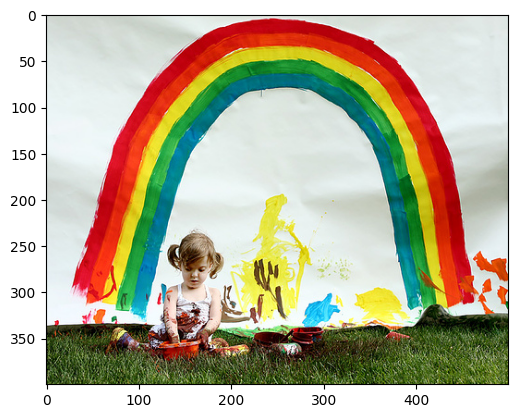

In [30]:
generate_caption("1002674143_1b742ab4b8.jpg")

---------------------Actual---------------------
startseq corgi runs out of tunnel endseq
startseq dog runs out of tunnel on course endseq
startseq dog running out of tunnel on obstacle course endseq
startseq the dog is running out of the tunnel on dog obedience course endseq
startseq the small brown and white dog is running out of small tunnel endseq
--------------------Predicted--------------------
startseq corgi runs out of tunnel endseq


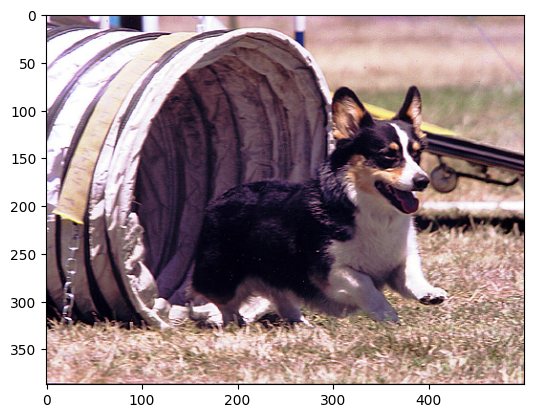

In [31]:
generate_caption("1095580424_76f0aa8a3e.jpg")

---------------------Actual---------------------
startseq black and white bird eating seeds out of someone hand endseq
startseq black and white bird standing on hand endseq
startseq small bird sits in person hand and eats seeds endseq
startseq black and white bird standing on hand of someone holding sunflower seeds endseq
startseq the small bird is clinging to finger of the hand holding the seeds endseq
--------------------Predicted--------------------
startseq the person is holding sunflower seeds endseq


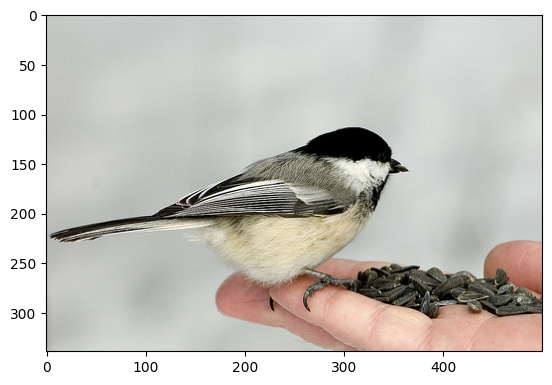

In [32]:
generate_caption("111766423_4522d36e56.jpg")

---------------------Actual---------------------
startseq man eats near tent in the snow endseq
startseq man sitting near tent in the snow and ice endseq
startseq mountaineer sits in the snow in front of yellow tent under clear blue sky endseq
startseq person wearing hooded jacket sitting on snow in front of yellow tent endseq
startseq young man in hooded jacket sitting on snow in mountain area endseq
--------------------Predicted--------------------
startseq mountaineer is sitting on the side of snow covered mountain endseq


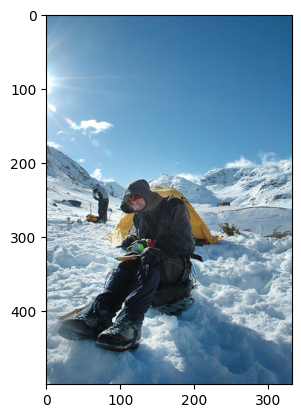

In [33]:
generate_caption("116409198_0fe0c94f3b.jpg")

---------------------Actual---------------------
startseq two men cleaning the outside windows of yacht endseq
startseq two men climb the side of boat endseq
startseq two men on the side of barge endseq
startseq two people outside cleaning windows while on ledge of boat endseq
startseq two people stand on the side of large white and red boat endseq
--------------------Predicted--------------------
startseq two men cleaning the side of the ocean endseq


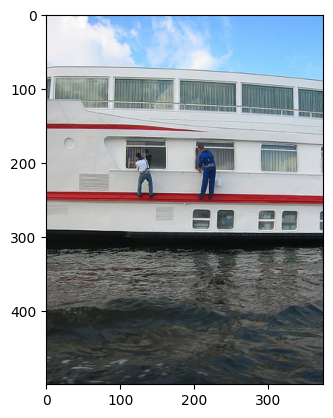

In [34]:
generate_caption("121971540_0a986ee176.jpg")

---------------------Actual---------------------
startseq dog in number six jersey is running through field endseq
startseq dog is leaping through the grass endseq
startseq dog is wearing red number and running through field of green grass while being chased by bird endseq
startseq white and tan dog leaps through the air endseq
startseq the dog in vest leaps in the air and there is bird flying endseq
--------------------Predicted--------------------
startseq dog jumps through the air endseq


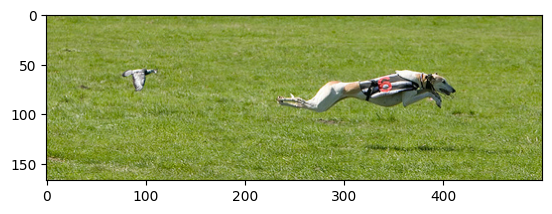

In [35]:
generate_caption("1240297429_c36ae0c58f.jpg")

---------------------Actual---------------------
startseq brown dog is leaping into garden swimming pool endseq
startseq brown dog leaps into swimming pool endseq
startseq brown fluffy dog jumping into swimming pool after red toy endseq
startseq dog jumps into swimming pool after toy endseq
startseq dog takes leap of faith as he jumps into pool to grab an orange toy endseq
--------------------Predicted--------------------
startseq brown dog jumping into swimming pool endseq


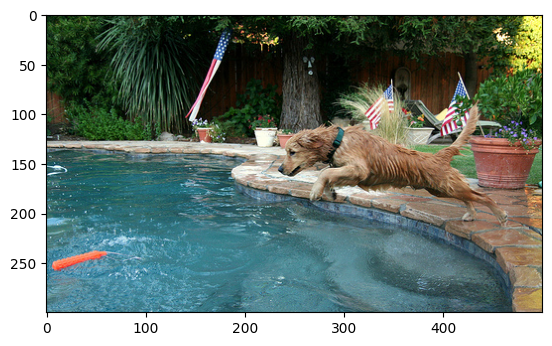

In [36]:
generate_caption("1288909046_d2b2b62607.jpg")

---------------------Actual---------------------
startseq girl in tank top and jean capris stands on railroad tracks endseq
startseq girl is standing barefoot on the railroad tracks endseq
startseq girl stands in the train tracks endseq
startseq young woman in jeans and tank top standing on railroad tracks endseq
startseq girl is standing out on the train tracks endseq
--------------------Predicted--------------------
startseq woman in tank top and jean capris and tshirt is standing on railroad tracks endseq


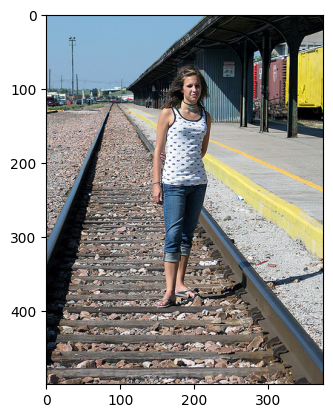

In [37]:
generate_caption("1303550623_cb43ac044a.jpg")

---------------------Actual---------------------
startseq girl in pigtails splashes in the shallow water endseq
startseq girls plays in the surf endseq
startseq girl with pigtails is playing in the ocean by the beach endseq
startseq girl with pigtails plays in the water endseq
startseq young girl in pigtails plays in the water endseq
--------------------Predicted--------------------
startseq woman in pigtails is walking on the sandy sandy beach endseq


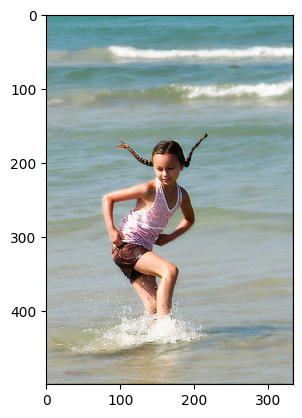

In [38]:
generate_caption("1053804096_ad278b25f1.jpg")

---------------------Actual---------------------
startseq crowd watching air balloons at night endseq
startseq group of hot air balloons lit up at night endseq
startseq people are watching hot air balloons in the park endseq
startseq people watching hot air balloons endseq
startseq seven large balloons are lined up at nighttime near crowd endseq
--------------------Predicted--------------------
startseq crowd watching the air balloons with the air endseq


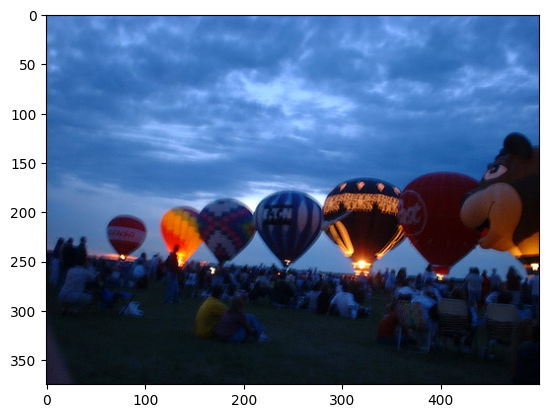

In [39]:
generate_caption("107318069_e9f2ef32de.jpg")